# 04 — Validação Interna das Hipóteses

## Objetivo

Validar **internamente** o indicador de qualificação da audiência construído no notebook anterior (`perfil_qualificacao`), verificando se os tiers se comportam de forma coerente com as expectativas teóricas. externa.

## Hipóteses
| Hipótese | Enunciado | Tipo |
|---|---|---|
| **H1** | Tiers superiores (A > B > C > D) apresentam **maior** ER clássico mediano. | Validade convergente |
| **H2** | Tiers superiores apresentam **menor** coeficiente de variação (CV) do ER. | Validade convergente |
| **H3** | O padrão de ordenação dos tiers se mantém **dentro dos segmentos** (`inf_category × bucket_followers`). | Coerência intrassegmento |
| **H4** | A distribuição dos tiers não colapsa sistematicamente em um único porte de perfil, indicando **ausência de viés estrutural forte por bucket**. | Equilíbrio estrutural |

<!-- | **H3** | Os resultados são **estáveis** quando se substitui `er_classico` por `er_weighted` na composição do score. | Robustez | -->

In [3]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import seaborn as sns
from pathlib import Path
from scipy.stats import spearmanr, kruskal, binomtest, chisquare, shapiro, probplot, norm
import scikit_posthocs as sp
import pymannkendall as mk
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from itertools import combinations
from statannotations.Annotator import Annotator

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13

ORDEM_TIER = ["D", "C", "B", "A"]
ORDEM_BUCKET = ["nano", "micro", "mid-tier", "macro", "mega"]

# 1. Carga da base

In [4]:
perfis = pl.read_parquet(Path("bases-processadas/perfil_qualificacao.parquet"))

print(perfis.shape)
perfis.head()

(33149, 21)


username,n_posts_total,followers,inf_category,bucket_followers,perfil_completo_lookup,erclassico_mediana,erclassico_media,erweighted_mediana,is_sponsored_pct,pct_image,pct_carousel,n_posts_validos,er_media,er_mediana,cv,elegivel,rank_er,rank_cv,score_audiencia,tier_audiencia
str,u32,f64,str,str,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,f64,f64,f64,str
"""amandaciurdar""",300,154600.0,"""family""","""mid-tier""",true,0.781048,0.836182,0.781048,0.066667,0.87,0.13,300.0,0.836182,0.781048,0.41133,true,0.049046,0.253406,0.328065,"""C"""
"""toastycritic""",300,2315.0,"""other""","""nano""",true,3.282937,5.072714,3.282937,0.02,0.953333,0.046667,300.0,5.072714,3.282937,0.845645,true,0.654265,0.777115,0.481713,"""C"""
"""travariscadet38""",94,62057.0,"""other""","""micro""",true,2.548464,2.915491,2.555715,0.031915,0.957447,0.042553,94.0,2.915491,2.548464,0.411845,true,0.656044,0.129121,0.741978,"""A"""
"""pixiedustsavings""",252,1578.0,"""other""","""nano""",true,1.457541,1.657211,1.489227,0.039683,1.0,0.0,252.0,1.657211,1.457541,0.501546,true,0.305721,0.365742,0.437136,"""C"""
"""ninahaveheart""",300,2091.0,"""travel""","""nano""",true,5.906265,6.268133,5.954089,0.003333,0.76,0.24,300.0,6.268133,5.906265,0.384236,true,0.582847,0.3979,0.590548,"""B"""


# 2. Sintese inicial

In [5]:
perfis = perfis.filter(pl.col("tier_audiencia") != "NaN")

In [6]:
resumo_tiers = (
    perfis
    .group_by("tier_audiencia")
    .agg([
        pl.len().alias("n_perfis"),
        pl.col("erclassico_mediana").median().alias("erclassico_mediana_mediana"),
        pl.col("cv").median().alias("cv_mediana"),
        pl.col("score_audiencia").median().alias("score_mediano"),
    ])
    .with_columns((pl.col("n_perfis") / pl.col("n_perfis").sum() * 100).alias("pct"))
    .with_columns(
        pl.col("tier_audiencia")
        .replace({tier: i for i, tier in enumerate(ORDEM_TIER)})
        .alias("ordem_tier")
    )
    .sort("ordem_tier")
    .drop("ordem_tier")
)
resumo_tiers

tier_audiencia,n_perfis,erclassico_mediana_mediana,cv_mediana,score_mediano,pct
str,u32,f64,f64,f64,f64
"""D""",8253,1.274028,0.714366,0.2,25.002272
"""C""",8252,2.469168,0.5083,0.417678,24.999243
"""B""",8252,3.862057,0.456189,0.592467,24.999243
"""A""",8252,6.298462,0.348333,0.792385,24.999243


# 3. Convergência - H1 e H2

Ambas hipoteses testam a ordenação interna dos tiers em suas dimensões do score

In [7]:
# agg_h1h2 = (perfis.group_by("tier_audiencia").agg([
#     pl.len().alias("n_perfis"),
#     pl.col("erclassico_mediana").median().alias("erclassico_mediana_mediana"),
#     pl.col("erclassico_mediana").mean().alias("erclassico_mediana_media"),
#     pl.col("cv").median().alias("cv_mediana"),
#     pl.col("cv").mean().alias("cv_media"),
#     pl.col("score_audiencia").median().alias("score_mediano"),
# ]).with_columns(pl.col("tier_audiencia").replace_strict(
#     {cat: i for i, cat in enumerate(ORDEM_TIER)},
#     default = len(ORDEM_TIER)
# ).alias("_ordem"))
# .sort("_ordem").drop("_ordem")
# )

In [8]:
# agg_h1h2

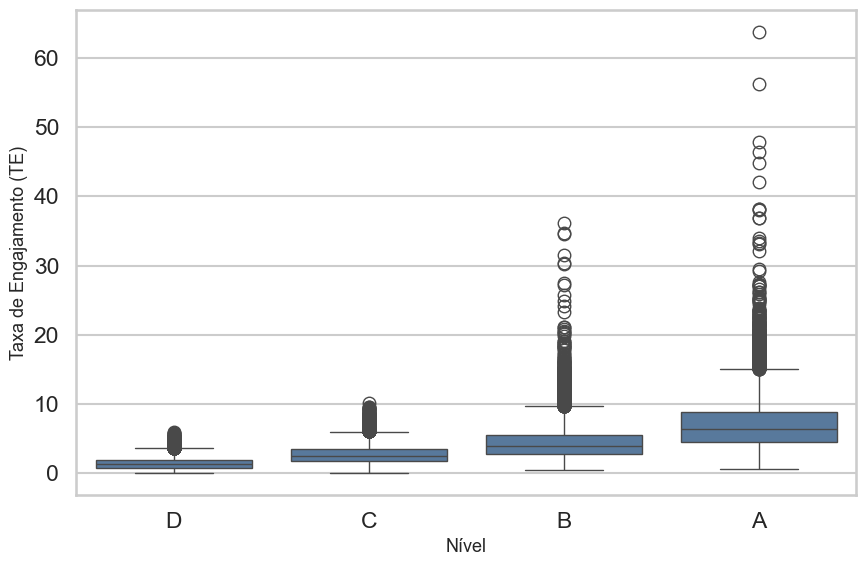

In [18]:
# Boxplot H1 — ER clássico mediano por tier
fig, ax = plt.subplots(figsize=(9, 6))

sns.boxplot(
    data=perfis, x="tier_audiencia", y="erclassico_mediana",
    order=ORDEM_TIER, color="#4C78A8", ax=ax
)
# ax.set_title("H1 — ER clássico mediano por tier de audiência")
ax.set_xlabel("Nível")
ax.set_ylabel("Taxa de Engajamento (TE)")

plt.tight_layout()
plt.savefig("output/fig_h1_boxplot_er_tier.png", dpi=150, bbox_inches="tight")
plt.show()


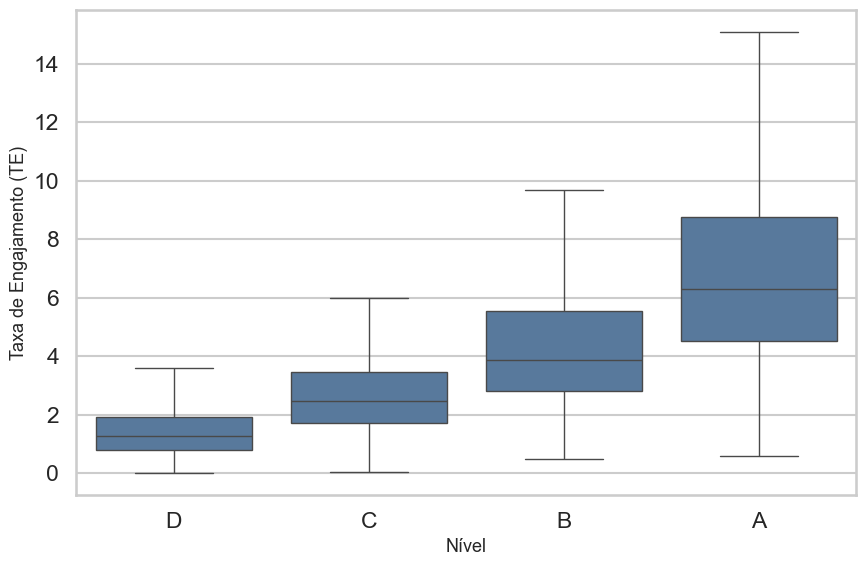

In [19]:
# Boxplot H1 - sem fliers
fig, ax = plt.subplots(figsize=(9, 6))

sns.boxplot(
    data=perfis, x="tier_audiencia", y="erclassico_mediana",
    order=ORDEM_TIER, color="#4C78A8", ax=ax,
    showfliers=False
)
# ax.set_title("H1 — ER clássico mediano por tier de audiência")
ax.set_xlabel("Nível")
ax.set_ylabel("Taxa de Engajamento (TE)")

plt.tight_layout()
plt.savefig("output/fig_h1_boxplot_er_tier_semfliers.png", dpi=150, bbox_inches="tight")
plt.show()


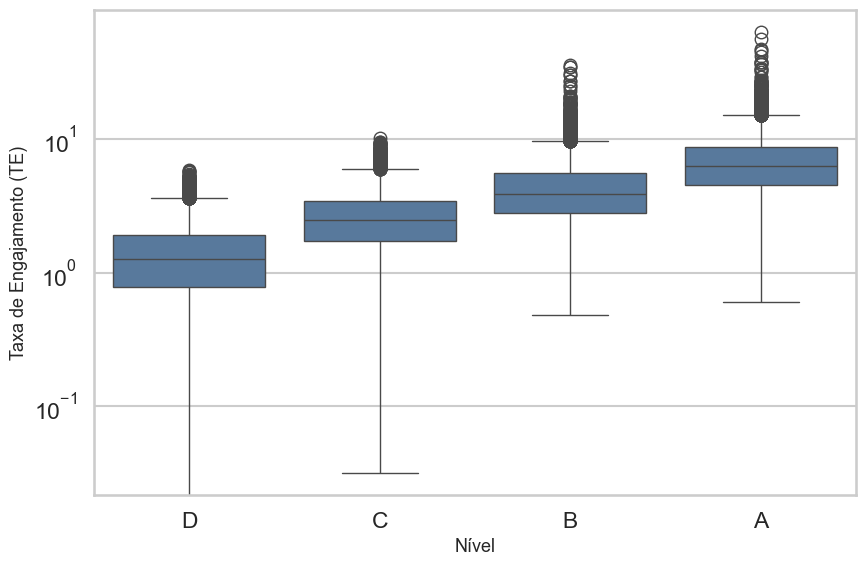

In [20]:
# Escala logarítimica
fig, ax = plt.subplots(figsize=(9, 6))

sns.boxplot(
    data=perfis, x="tier_audiencia", y="erclassico_mediana",
    order=ORDEM_TIER, color="#4C78A8", ax=ax
)
# ax.set_title("H1 — ER clássico mediano por tier de audiência")
ax.set_xlabel("Nível")
ax.set_ylabel("Taxa de Engajamento (TE)")
ax.set_yscale("log")

plt.tight_layout()
plt.savefig("output/fig_h1_boxplot_er_tier_log.png", dpi=150, bbox_inches="tight")
plt.show()

<Axes: xlabel='tier_audiencia', ylabel='erclassico_mediana'>

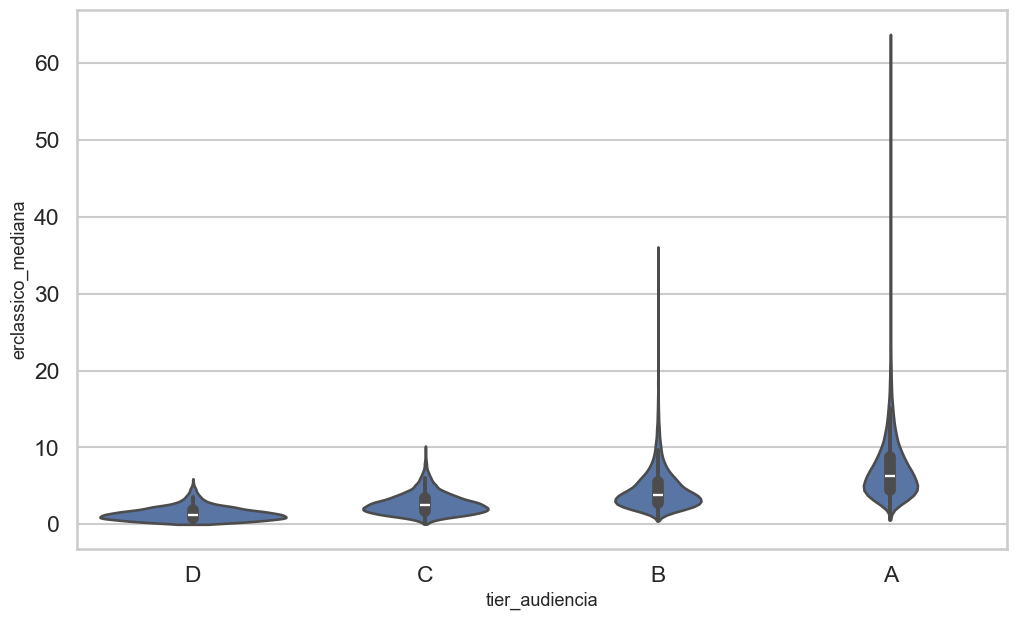

In [24]:
sns.violinplot(data=perfis, x="tier_audiencia", y="erclassico_mediana",
               order=["D","C","B","A"], inner="box", cut=0)

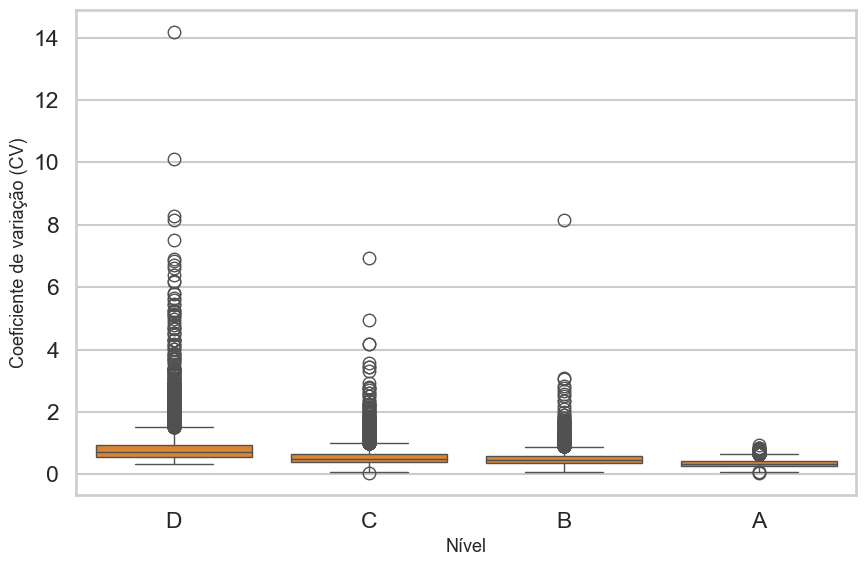

In [21]:
# Boxplot H2 — CV por tier
fig, ax = plt.subplots(figsize=(9, 6))

sns.boxplot(
    data=perfis, x="tier_audiencia", y="cv",
    order=ORDEM_TIER, color="#F58518", ax=ax
)
# ax.set_title("H2 — Coeficiente de variação (CV) por tier de audiência")
ax.set_xlabel("Nível")
ax.set_ylabel("Coeficiente de variação (CV)")

plt.tight_layout()
plt.savefig("output/fig_h2_boxplot_cv_tier.png", dpi=150, bbox_inches="tight")
plt.show()


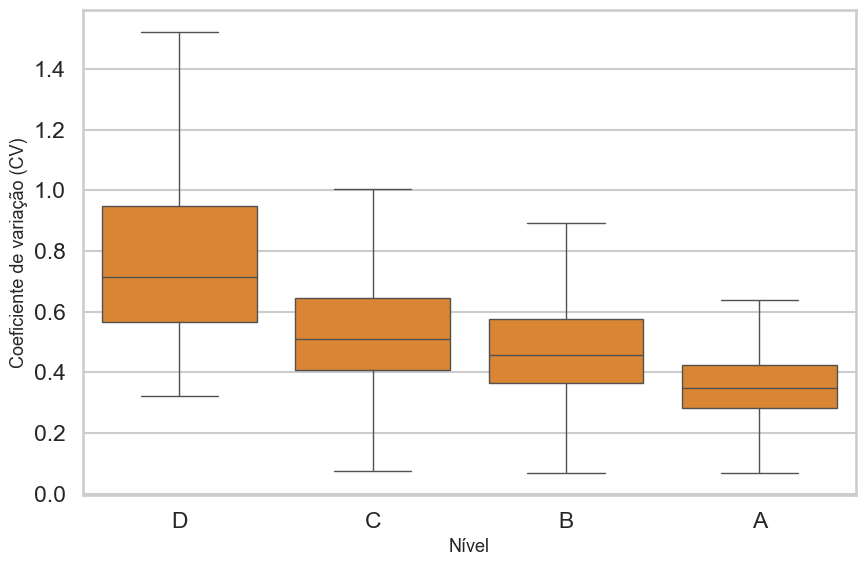

In [22]:
# Boxplot H2 - sem fliers
fig, ax = plt.subplots(figsize=(9, 6))

sns.boxplot(
    data=perfis, x="tier_audiencia", y="cv",
    order=ORDEM_TIER, color="#F58518", ax=ax,
    showfliers=False
)
# ax.set_title("H2 — Coeficiente de variação (CV) por tier de audiência")
ax.set_xlabel("Nível")
ax.set_ylabel("Coeficiente de variação (CV)")

plt.tight_layout()
plt.savefig("output/fig_h2_boxplot_cv_tier_semfliers.png", dpi=150, bbox_inches="tight")
plt.show()


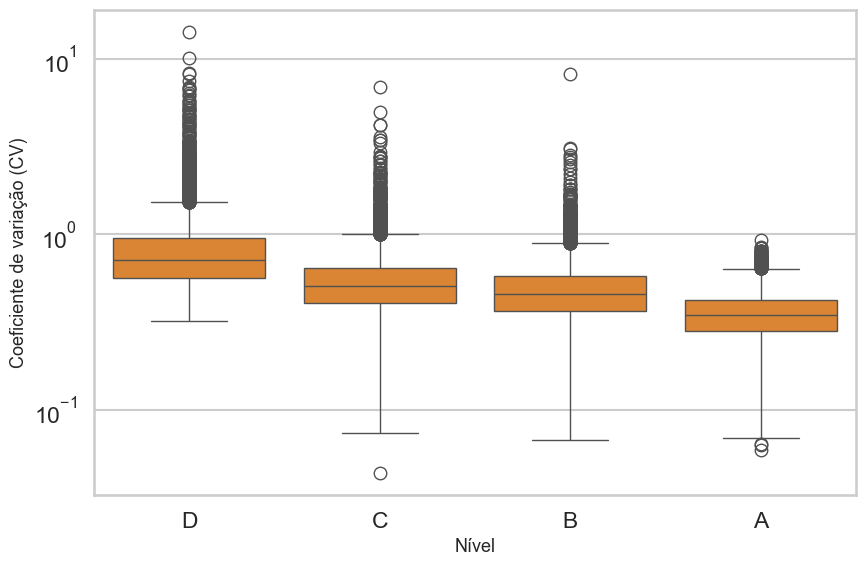

In [23]:
# Escala Logarítimica
fig, ax = plt.subplots(figsize=(9, 6))

sns.boxplot(
    data=perfis, x="tier_audiencia", y="cv",
    order=ORDEM_TIER, color="#F58518", ax=ax
)
# ax.set_title("H2 — Coeficiente de variação (CV) por tier de audiência")
ax.set_xlabel("Nível")
ax.set_ylabel("Coeficiente de variação (CV)")
ax.set_yscale("log")

plt.tight_layout()
plt.savefig("output/fig_h2_boxplot_cv_tier_log.png", dpi=150, bbox_inches="tight")
plt.show()


<Axes: xlabel='tier_audiencia', ylabel='cv'>

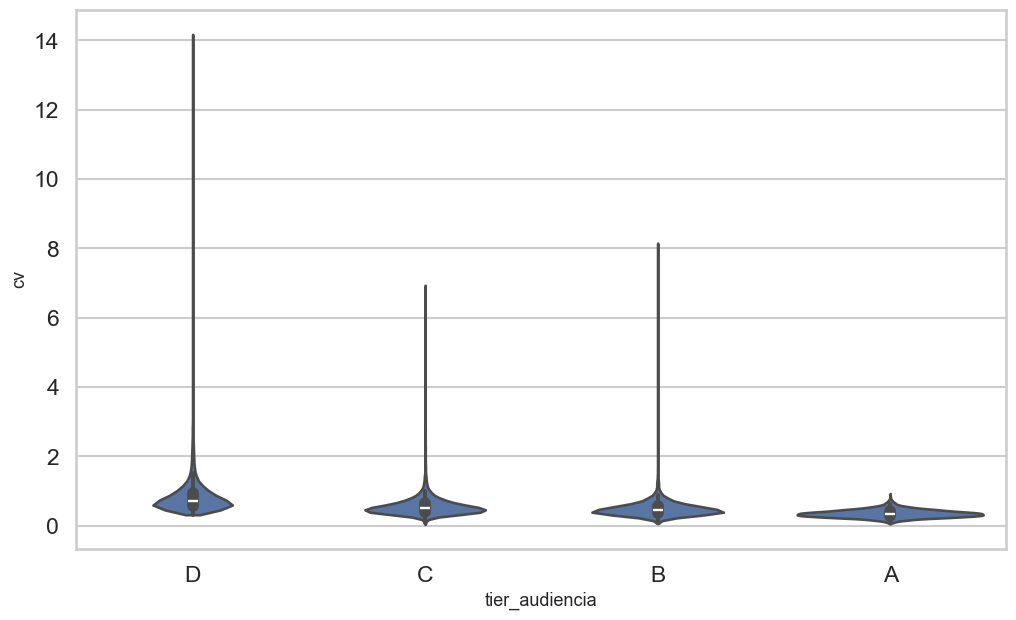

In [27]:
sns.violinplot(data=perfis, x="tier_audiencia", y="cv",
               order=["D","C","B","A"], inner="box", cut=0)

- Média e DP

In [28]:
# Calcular média e desvio padrão por tier
stats = (
    perfis
    .group_by("tier_audiencia")
    .agg(
        pl.col("erclassico_mediana").mean().alias("te_mean"),
        pl.col("erclassico_mediana").std().alias("te_std"),
        pl.col("cv").mean().alias("cv_mean"),
        pl.col("cv").std().alias("cv_std"),
    )
    .with_columns(
        pl.col("tier_audiencia")
          .replace({tier: i for i, tier in enumerate(ORDEM_TIER)})
          .alias("ordem")
    )
    .sort("ordem")
    .drop("ordem")
    .to_pandas()
)

# Figura com dois subplots lado a lado
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        "Taxa de Engajamento (TE) — Média ± Desvio Padrão",
        "Coeficiente de Variação (CV) — Média ± Desvio Padrão"
    )
)

fig.add_trace(
    go.Bar(
        name="TE",
        x=stats["tier_audiencia"],
        y=stats["te_mean"],
        error_y=dict(type="data", array=stats["te_std"]),
        marker_color="#4C72B0",
    ),
    row=1, col=1
)

fig.add_trace(
    go.Bar(
        name="CV",
        x=stats["tier_audiencia"],
        y=stats["cv_mean"],
        error_y=dict(type="data", array=stats["cv_std"]),
        marker_color="#DD8452",
    ),
    row=1, col=2
)

fig.update_layout(
    template="none",
    paper_bgcolor="#f7f8fa",
    font=dict(family="Arial", size=13, color="black"),
    margin=dict(l=75, r=20, t=75, b=75),
    width=1200,
    height=500,
    showlegend=False,
)

fig.update_xaxes(title_text="<b>Nível de Audiência", row=1, col=1)
fig.update_xaxes(title_text="<b>Nível de Audiência", row=1, col=2)
fig.update_yaxes(title_text="<b>TE (%)", row=1, col=1)
fig.update_yaxes(title_text="<b>CV", row=1, col=2)

fig.write_image("output/fig_media_dp_te_cv.png", scale=2)
fig.show()

In [29]:
# Estatísticas por tier
stats = (
    perfis
    .group_by("tier_audiencia")
    .agg(
        pl.col("erclassico_mediana").median().alias("te_median"),
        pl.col("erclassico_mediana").quantile(0.25).alias("te_q1"),
        pl.col("erclassico_mediana").quantile(0.75).alias("te_q3"),
        pl.col("cv").median().alias("cv_median"),
        pl.col("cv").quantile(0.25).alias("cv_q1"),
        pl.col("cv").quantile(0.75).alias("cv_q3"),
    )
    .with_columns(
        pl.col("tier_audiencia")
          .replace({tier: i for i, tier in enumerate(ORDEM_TIER)})
          .alias("ordem")
    )
    .sort("ordem")
    .drop("ordem")
    .to_pandas()
)

# Figura
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        "Taxa de Engajamento - Mediana ± IQR",
        "Coeficiente de Variação - Mediana ± IQR"
    ),
    horizontal_spacing=0.12
)

# H1 — TE
fig.add_trace(
    go.Bar(
        name="TE",
        x=stats["tier_audiencia"],
        y=stats["te_median"],
        error_y=dict(
            type="data",
            symmetric=False,
            array=(stats["te_q3"] - stats["te_median"]).tolist(),
            arrayminus=(stats["te_median"] - stats["te_q1"]).tolist(),
            color="#2c5f8a",
            thickness=2,
            width=8,
        ),
        marker_color="#4C72B0",
        marker_line=dict(color="#2c5f8a", width=1),
        width=0.5,
    ),
    row=1, col=1
)

# H2 — CV
fig.add_trace(
    go.Bar(
        name="CV",
        x=stats["tier_audiencia"],
        y=stats["cv_median"],
        error_y=dict(
            type="data",
            symmetric=False,
            array=(stats["cv_q3"] - stats["cv_median"]).tolist(),
            arrayminus=(stats["cv_median"] - stats["cv_q1"]).tolist(),
            color="#8a4c1e",
            thickness=2,
            width=8,
        ),
        marker_color="#DD8452",
        marker_line=dict(color="#8a4c1e", width=1),
        width=0.5,
    ),
    row=1, col=2
)

fig.update_layout(
    template="none",
    paper_bgcolor="#ffffff",
    plot_bgcolor="#ffffff",
    font=dict(family="Arial", size=13, color="black"),
    margin=dict(l=70, r=30, t=70, b=60),
    width=1100,
    height=480,
    showlegend=False,
)

# Eixos
fig.update_xaxes(title_text="<b>Nível de Audiência", row=1, col=1,
                 categoryorder="array", categoryarray=["D", "C", "B", "A"])
fig.update_xaxes(title_text="<b>Nível de Audiência", row=1, col=2,
                 categoryorder="array", categoryarray=["D", "C", "B", "A"])
fig.update_yaxes(title_text="<b>TE (%)", row=1, col=1,
                 gridcolor="#eeeeee", zeroline=False)
fig.update_yaxes(title_text="<b>CV", row=1, col=2,
                 gridcolor="#eeeeee", zeroline=False)

fig.write_image("output/fig_mediana_iqr_te_cv.png", scale=2)
fig.show()

- IQR(intervalo quartil ou amplitude interquartil): Barra de erro superior = Q3 - mediana e Barra de erro inferior = mediana - Q1

# Teste de Normalidade + Plotagem

In [30]:
variaveis = {
    "TE (erclassicomediana)": "erclassico_mediana",
    "CV": "cv"
}

AMOSTRA_MAX = 5000

- Shapiro: p < 0.05 rejeita a normalidade

In [31]:
print(f"{'Variável':<30} {'Tier':<6} {'W':>10} {'p-valor':>14} {'Normal?'}")
for nome_var, col in variaveis.items():
    for tier in ORDEM_TIER:
        dados = (
            perfis
            .filter(pl.col("tier_audiencia") == tier)
            .select(col)
            .drop_nulls()
            .to_series()
            .to_list()
        )
        if len(dados) > AMOSTRA_MAX:
            import random
            random.seed(42)
            dados = random.sample(dados, AMOSTRA_MAX)
        
        stat, p = shapiro(dados)
        normal = "Sim" if p >= 0.05 else "Não"
        print(f"{nome_var:<30} {tier:<6} {stat:>10.4f} {p:>14.6f} {normal}")
    print()

Variável                       Tier            W        p-valor Normal?
TE (erclassicomediana)         D          0.9267       0.000000 Não
TE (erclassicomediana)         C          0.9369       0.000000 Não
TE (erclassicomediana)         B          0.8050       0.000000 Não
TE (erclassicomediana)         A          0.8279       0.000000 Não

CV                             D          0.6010       0.000000 Não
CV                             C          0.7700       0.000000 Não
CV                             B          0.6831       0.000000 Não
CV                             A          0.9812       0.000000 Não



- Histogramas

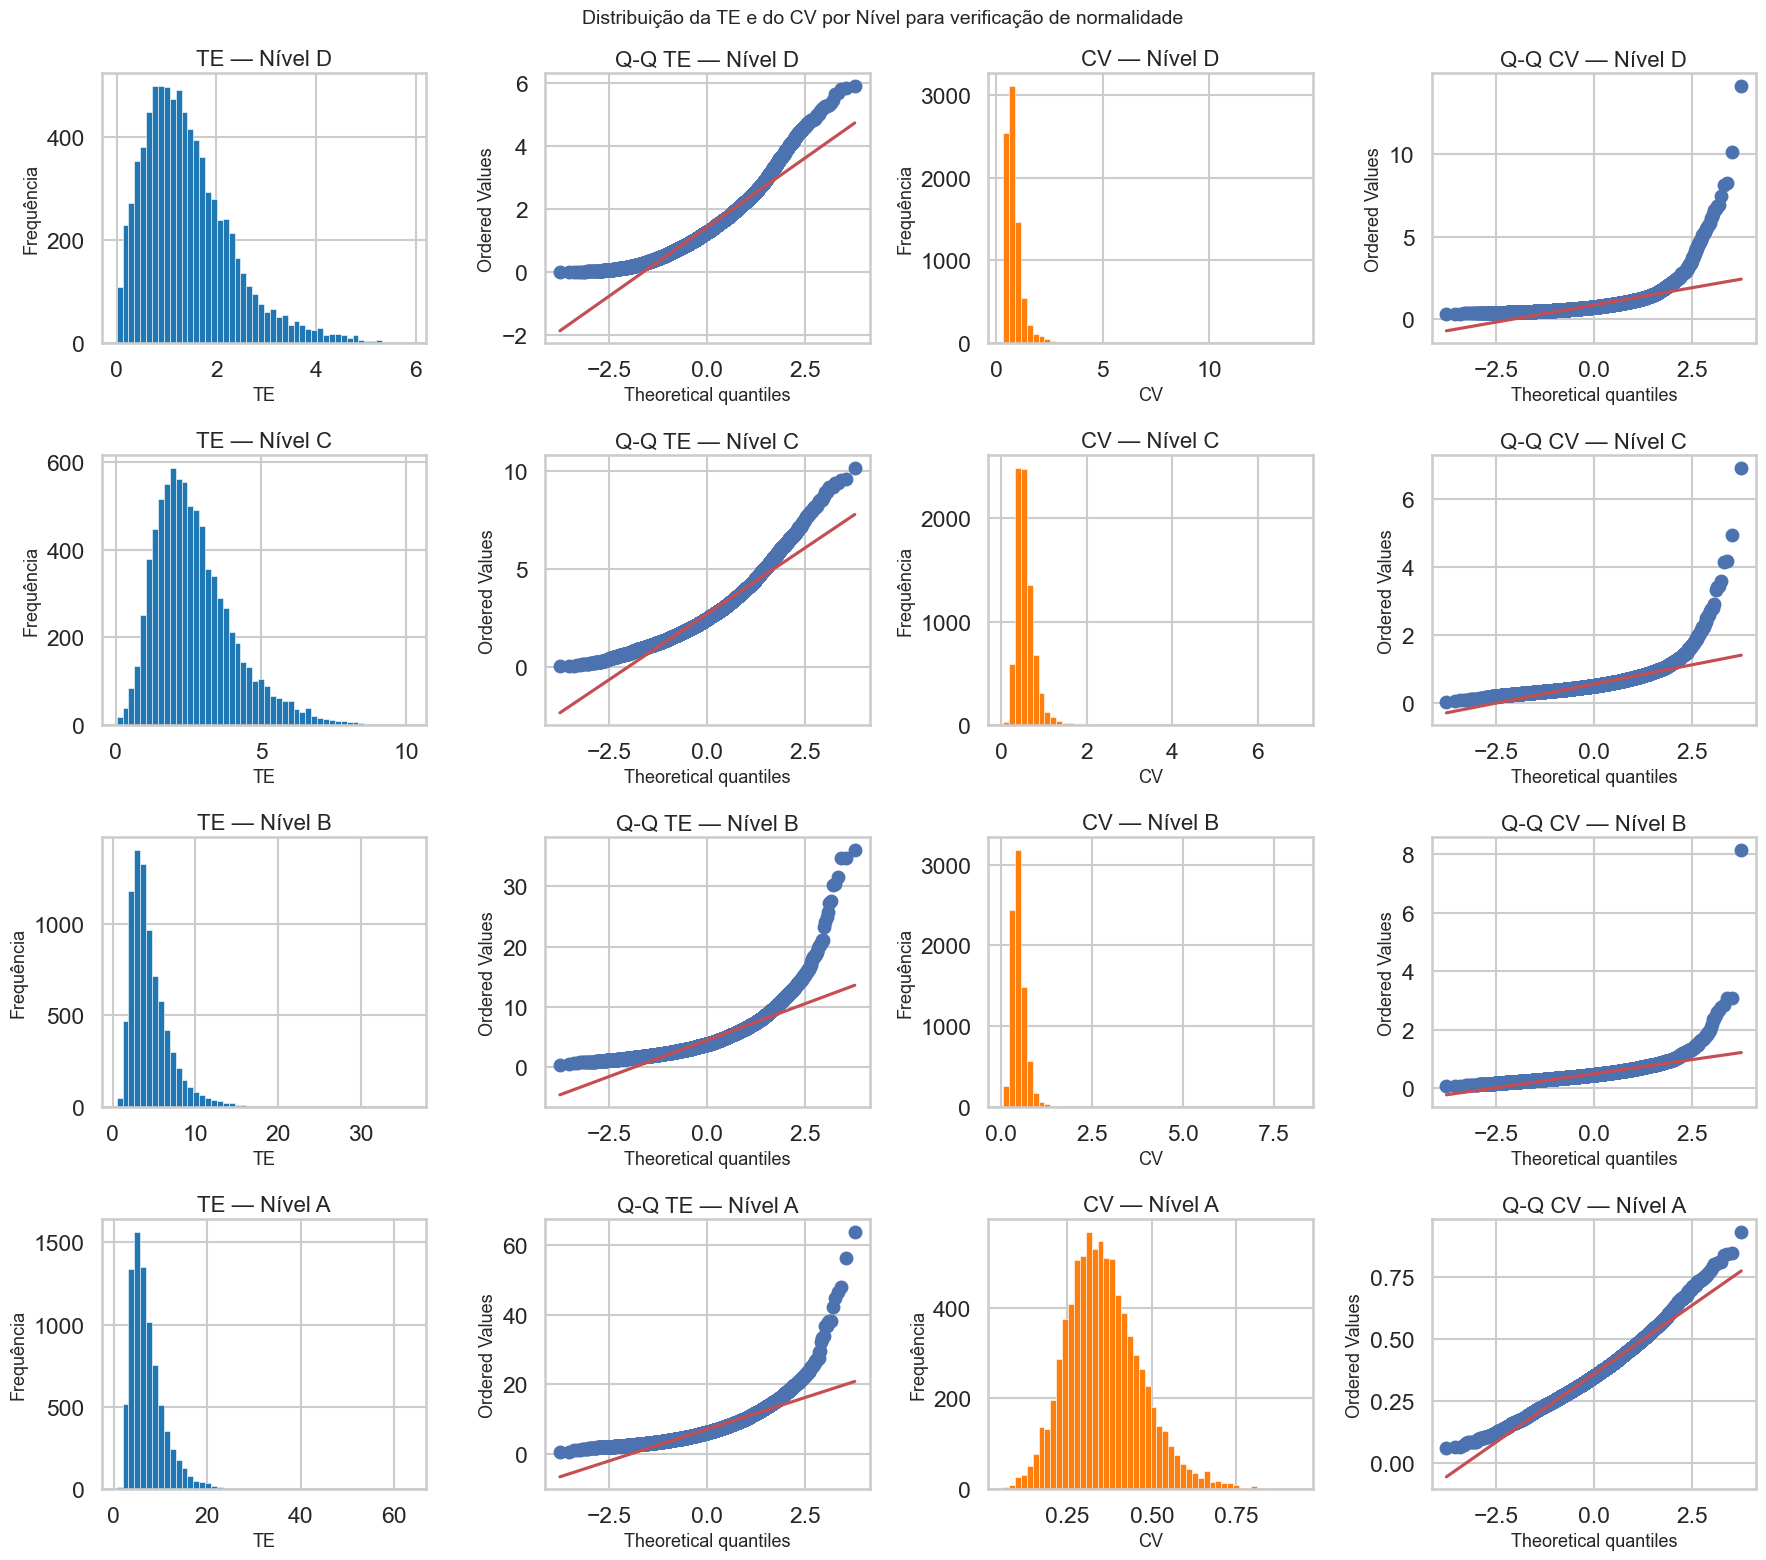

In [32]:
fig, axes = plt.subplots(4, 4, figsize=(18, 16))
fig.suptitle("Distribuição da TE e do CV por Nível para verificação de normalidade", fontsize=14)

for i, tier in enumerate(ORDEM_TIER):
    dados_te = (
        perfis.filter(pl.col("tier_audiencia") == tier)
        .select("erclassico_mediana").drop_nulls()
        .to_series().to_numpy()
    )
    dados_cv = (
        perfis.filter(pl.col("tier_audiencia") == tier)
        .select("cv").drop_nulls()
        .to_series().to_numpy()
    )

    # Histograma TE
    axes[i, 0].hist(dados_te, bins=50, color="#1f77b4", edgecolor="white", linewidth=0.4)
    axes[i, 0].set_title(f"TE — Nível {tier}")
    axes[i, 0].set_xlabel("TE"); axes[i, 0].set_ylabel("Frequência")

    # Q-Q TE
    probplot(dados_te, dist="norm", plot=axes[i, 1])
    axes[i, 1].set_title(f"Q-Q TE — Nível {tier}")

    # Histograma CV
    axes[i, 2].hist(dados_cv, bins=50, color="#ff7f0e", edgecolor="white", linewidth=0.4)
    axes[i, 2].set_title(f"CV — Nível {tier}")
    axes[i, 2].set_xlabel("CV"); axes[i, 2].set_ylabel("Frequência")

    # Q-Q CV
    probplot(dados_cv, dist="norm", plot=axes[i, 3])
    axes[i, 3].set_title(f"Q-Q CV — Nível {tier}")

plt.tight_layout()
plt.savefig("output/fig_normalidade_te_cv.png", dpi=150, bbox_inches="tight")
plt.show()

## Kruskal-Wallis

### H1

In [33]:
grupos_h1 = [
    perfis.filter(pl.col("tier_audiencia") == t)["erclassico_mediana"].to_list()
    for t in ORDEM_TIER
]

In [34]:
stat_h1, p_h1 = kruskal(*grupos_h1)
print(f"H1 — Kruskal-Wallis: H={stat_h1:.4f}, p={p_h1:.14f}")
print("Interpretação: rejeita H0 (distribuições iguais)" if p_h1 < 0.05 else "Interpretação: não rejeita H0")

H1 — Kruskal-Wallis: H=19620.8648, p=0.00000000000000
Interpretação: rejeita H0 (distribuições iguais)


    - Post-hoc Dunn com Bonferroni

In [35]:
df_dunn = perfis.select(["tier_audiencia", "erclassico_mediana"]).to_pandas()

resultado_h1 = sp.posthoc_dunn(
    df_dunn,
    val_col="erclassico_mediana",
    group_col="tier_audiencia",
    p_adjust="bonferroni"
)
print("H1 — Post-hoc Dunn (Bonferroni):")
print(resultado_h1)

H1 — Post-hoc Dunn (Bonferroni):
     A    B    C    D
A  1.0  0.0  0.0  0.0
B  0.0  1.0  0.0  0.0
C  0.0  0.0  1.0  0.0
D  0.0  0.0  0.0  1.0


In [36]:
pares_adj = [("D","C"), ("C","B"), ("B","A")]
print("\nPares adjacentes (p < 0.05 = separação confirmada):")
for a, b in pares_adj:
    p = resultado_h1.loc[a, b]
    print(f"  {a} <-> {b}: p = {p:.2e} -> {'DISTINTO' if p < 0.05 else 'NÃO DISTINTO'}")


Pares adjacentes (p < 0.05 = separação confirmada):
  D <-> C: p = 0.00e+00 -> DISTINTO
  C <-> B: p = 0.00e+00 -> DISTINTO
  B <-> A: p = 0.00e+00 -> DISTINTO


    - Post-hoc de Dunn (Sem Bonferroni)

In [37]:
df_dunn = perfis.select(["tier_audiencia", "erclassico_mediana"]).to_pandas()

resultado_h1_2 = sp.posthoc_dunn(
    df_dunn,
    val_col="erclassico_mediana",
    group_col="tier_audiencia",
)
print("H1 — Post-hoc Dunn:")
print(resultado_h1_2)

H1 — Post-hoc Dunn:
     A    B    C    D
A  1.0  0.0  0.0  0.0
B  0.0  1.0  0.0  0.0
C  0.0  0.0  1.0  0.0
D  0.0  0.0  0.0  1.0


In [38]:
pares_adj = [("D","C"), ("C","B"), ("B","A")]
print("\nPares adjacentes (p < 0.05 = separação confirmada):")
for a, b in pares_adj:
    p = resultado_h1_2.loc[a, b]
    print(f"  {a} <-> {b}: p = {p:.2e} -> {'DISTINTO' if p < 0.05 else 'NÃO DISTINTO'}")


Pares adjacentes (p < 0.05 = separação confirmada):
  D <-> C: p = 0.00e+00 -> DISTINTO
  C <-> B: p = 0.00e+00 -> DISTINTO
  B <-> A: p = 0.00e+00 -> DISTINTO


### H2

In [39]:
grupos_h2 = [
    perfis.filter(pl.col("tier_audiencia") == t)["cv"].to_list()
    for t in ORDEM_TIER
]

In [40]:
stat_h2, p_h2 = kruskal(*grupos_h2)
print(f"H2 — Kruskal-Wallis: H={stat_h2:.4f}, p={p_h2:.14f}")
print("Interpretação: rejeita H0 (distribuições iguais)" if p_h2 < 0.05 else "Interpretação: não rejeita H0")

H2 — Kruskal-Wallis: H=13277.4305, p=0.00000000000000
Interpretação: rejeita H0 (distribuições iguais)


    - Post-hoc Dunn com Bonferroni

In [41]:
df_dunn_h2 = perfis.select(["tier_audiencia", "cv"]).to_pandas()
resultado_h2 = sp.posthoc_dunn(
    df_dunn_h2, val_col="cv",
    group_col="tier_audiencia",
    p_adjust="bonferroni"
)
print("H2 — Pós-hoc Dunn (Bonferroni):")
print(resultado_h2)

H2 — Pós-hoc Dunn (Bonferroni):
     A             B             C    D
A  1.0  0.000000e+00  0.000000e+00  0.0
B  0.0  1.000000e+00  1.566890e-77  0.0
C  0.0  1.566890e-77  1.000000e+00  0.0
D  0.0  0.000000e+00  0.000000e+00  1.0


In [42]:
pares_adj = [("D","C"), ("C","B"), ("B","A")]
print("\nPares adjacentes (p < 0.05 = separação confirmada):")
for a, b in pares_adj:
    p = resultado_h2.loc[a, b]
    print(f"  {a} <-> {b}: p = {p:.2e} -> {'DISTINTO' if p < 0.05 else 'NÃO DISTINTO'}")


Pares adjacentes (p < 0.05 = separação confirmada):
  D <-> C: p = 0.00e+00 -> DISTINTO
  C <-> B: p = 1.57e-77 -> DISTINTO
  B <-> A: p = 0.00e+00 -> DISTINTO


    - Post-hoc de Dunn (Sem Bonferroni)

In [43]:
df_dunn_h2 = perfis.select(["tier_audiencia", "cv"]).to_pandas()

resultado_h2_2 = sp.posthoc_dunn(
    df_dunn_h2, val_col="cv",
    group_col="tier_audiencia"
)

print("H2 — Pós-hoc Dunn:")
print(resultado_h2_2)

H2 — Pós-hoc Dunn:
     A             B             C    D
A  1.0  0.000000e+00  0.000000e+00  0.0
B  0.0  1.000000e+00  2.611483e-78  0.0
C  0.0  2.611483e-78  1.000000e+00  0.0
D  0.0  0.000000e+00  0.000000e+00  1.0


In [44]:
pares_adj = [("D","C"), ("C","B"), ("B","A")]
print("\nPares adjacentes (p < 0.05 = separação confirmada):")
for a, b in pares_adj:
    p = resultado_h2_2.loc[a, b]
    print(f"  {a} <-> {b}: p = {p:.2e} -> {'DISTINTO' if p < 0.05 else 'NÃO DISTINTO'}")


Pares adjacentes (p < 0.05 = separação confirmada):
  D <-> C: p = 0.00e+00 -> DISTINTO
  C <-> B: p = 2.61e-78 -> DISTINTO
  B <-> A: p = 0.00e+00 -> DISTINTO


# 4. Distribuição do Score

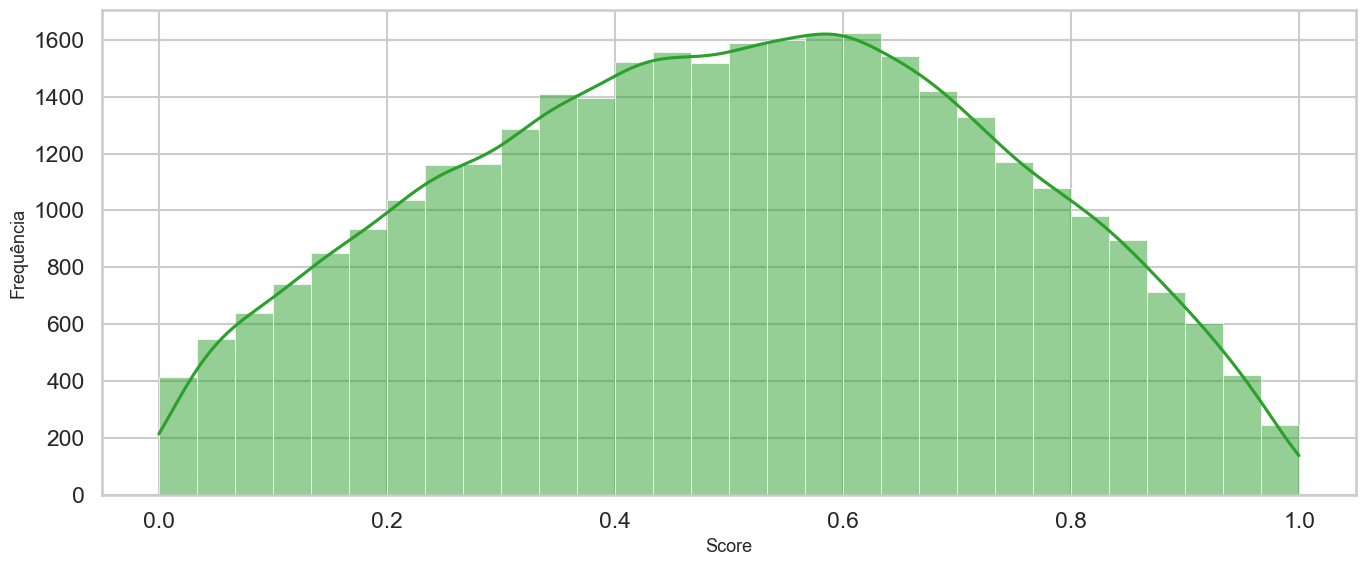

In [76]:
# Histograma da distribuição do score de audiência
fig, ax = plt.subplots(figsize=(14, 6))

sns.histplot(
    perfis["score_audiencia"], bins=30, kde=True,
    ax=ax, color="#2ca02c", edgecolor="white", linewidth=0.5
)
# ax.set_title("Distribuição do score de audiência")
ax.set_xlabel("Score")
ax.set_ylabel("Frequência")

plt.tight_layout()
plt.savefig("output/fig_histograma_score.png", dpi=150, bbox_inches="tight")
plt.show()


<!-- # 5. Estabilidade ao substituir ER classico por ER ponderado - H3 -->
# Hipotese com er  ponderado removida por hora

In [56]:
if "tier_audiencia_alt" not in perfis.columns:
    if "erweighted_mediana" not in perfis.columns:
        raise ValueError("A base não contém 'tier_audiencia_alt' nem 'erweighted_mediana' para reconstrução da alternativa.")

    alt = perfis.with_columns([
        pl.col("erweighted_mediana").rank(method="average").over(["inf_category", "bucket_followers"]).alias("rk_erw"),
        pl.len().over(["inf_category", "bucket_followers"]).alias("n_seg")
    ]).with_columns([
        ((pl.col("rk_erw") - 1) / (pl.col("n_seg") - 1)).fill_nan(0.5).fill_null(0.5).alias("pct_erweighted_mediana_alt"),
        (1 - pl.col("cv").rank(method="average").over(["inf_category", "bucket_followers"]).sub(1)
           .truediv(pl.len().over(["inf_category", "bucket_followers"]) - 1)).fill_nan(0.5).fill_null(0.5).alias("pct_cv_invertido_alt")
    ]).with_columns([
        (0.60 * pl.col("pct_erweighted_mediana_alt") + 0.40 * pl.col("pct_cv_invertido_alt")).mul(100).alias("score_audiencia_alt")
    ])

    q1 = alt.select(pl.col("score_audiencia_alt").quantile(0.25)).item()
    q2 = alt.select(pl.col("score_audiencia_alt").quantile(0.50)).item()
    q3 = alt.select(pl.col("score_audiencia_alt").quantile(0.75)).item()

    alt = alt.with_columns(
        pl.when(pl.col("score_audiencia_alt") <= q1).then(pl.lit("D"))
        .when(pl.col("score_audiencia_alt") <= q2).then(pl.lit("C"))
        .when(pl.col("score_audiencia_alt") <= q3).then(pl.lit("B"))
        .otherwise(pl.lit("A")).alias("tier_audiencia_alt")
    )

    perfis_valid = alt
    df_pd = perfis_valid.to_pandas()

matriz = pd.crosstab(df_pd["tier_audiencia"], df_pd["tier_audiencia_alt"], normalize="index").reindex(index=ORDEM_TIER, columns=ORDEM_TIER)
matriz


tier_audiencia_alt,D,C,B,A
tier_audiencia,,,,
D,0.997698,0.002302,0.000000,0.00000
C,0.002302,0.994547,0.003151,0.00000
B,0.000000,0.003151,0.993820,0.00303
A,0.000000,0.000000,0.003030,0.99697


In [57]:
# plt.figure(figsize=(8, 6))
# sns.heatmap(matriz, annot=True, fmt=".3f", cmap="Blues")
# plt.title("H3 - Concordância entre tiers original e alternativo")
# plt.xlabel("Tier alternativo")
# plt.ylabel("Tier original")
# plt.tight_layout()
# plt.show()

# 6. Coerencia intrasegmento - H3

In [58]:
segmento_stats = (
    perfis_valid
    .group_by(["inf_category", "bucket_followers", "tier_audiencia"])
    .agg([
        pl.len().alias("n_perfis"),
        pl.col("erclassico_mediana").median().alias("er_mediano"),
        pl.col("cv").median().alias("cv_mediano"),
        pl.col("score_audiencia").median().alias("score_mediano"),
    ])
    .with_columns(pl.col("tier_audiencia").cast(pl.Enum(ORDEM_TIER)))
    .sort(["inf_category", "bucket_followers", "tier_audiencia"])
)

- Verificar monotonicidade por segmento

In [59]:
checks_df = (
    segmento_stats
    .with_columns([
        pl.col("tier_audiencia").n_unique().over(["inf_category", "bucket_followers"]).alias("n_tiers"),
        pl.col("er_mediano").diff().over(["inf_category", "bucket_followers"]).alias("diff_er"),
        pl.col("cv_mediano").diff().over(["inf_category", "bucket_followers"]).alias("diff_cv"),
        pl.col("score_mediano").diff().over(["inf_category", "bucket_followers"]).alias("diff_score"),
    ])
    .filter(pl.col("n_tiers") == 4)
    .group_by(["inf_category", "bucket_followers"])
    .agg([
        (pl.col("diff_er").drop_nulls() > 0).all().alias("monotonia_er"),
        (pl.col("diff_cv").drop_nulls() < 0).all().alias("monotonia_cv"),
        (pl.col("diff_score").drop_nulls() > 0).all().alias("monotonia_score"),
    ])
    .with_columns(
        pl.all_horizontal("monotonia_er", "monotonia_cv", "monotonia_score").alias("segmento_ok_total")
    )
)

In [60]:
checks_df

inf_category,bucket_followers,monotonia_er,monotonia_cv,monotonia_score,segmento_ok_total
str,str,bool,bool,bool,bool
"""beauty""","""nano""",true,true,true,true
"""family""","""nano""",true,true,true,true
"""interior""","""macro""",true,false,true,false
"""family""","""mega""",true,true,true,true
"""food""","""macro""",true,true,true,true
…,…,…,…,…,…
"""travel""","""mega""",true,true,true,true
"""other""","""micro""",true,true,true,true
"""beauty""","""mid-tier""",true,true,true,true


In [61]:
resumo_h4 = pl.DataFrame({
    "criterio": ["Monotonia do ER", "Monotonia do CV", "Monotonia do score", "Todos os critérios"],
    "proporcao_segmentos": (
        [
            checks_df["monotonia_er"].mean(),
            checks_df["monotonia_cv"].mean(),
            checks_df["monotonia_score"].mean(),
            checks_df["segmento_ok_total"].mean(),
        ]
        if len(checks_df) else
        [float("nan")] * 4
    )
})
resumo_h4

criterio,proporcao_segmentos
str,f64
"""Monotonia do ER""",0.977273
"""Monotonia do CV""",0.954545
"""Monotonia do score""",1.0
"""Todos os critérios""",0.954545


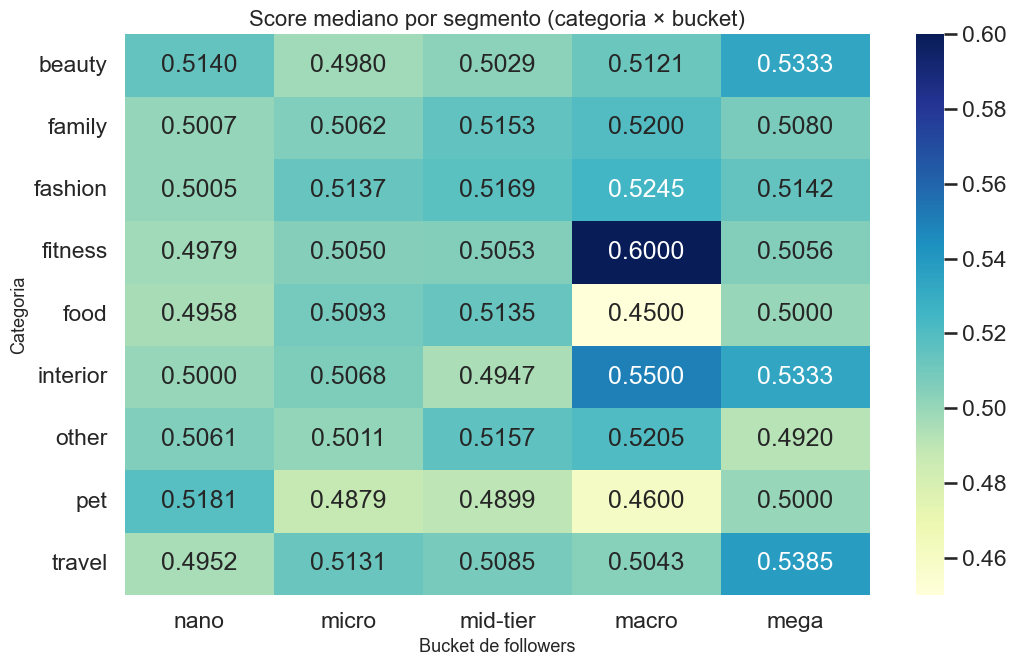

In [62]:
pivot_score = (
    perfis_valid
    .group_by(["inf_category", "bucket_followers"])
    .agg(pl.col("score_audiencia").median().alias("score_mediano"))
    .to_pandas()
    .pivot(index="inf_category", columns="bucket_followers", values="score_mediano")
    .reindex(columns=ORDEM_BUCKET)
)

plt.figure(figsize=(11, 7))
sns.heatmap(pivot_score, annot=True, fmt=".4f", cmap="YlGnBu")
plt.title("Score mediano por segmento (categoria × bucket)")
plt.xlabel("Bucket de followers")
plt.ylabel("Categoria")
plt.tight_layout()
plt.show()

### Teste Binomial para H3

In [63]:
n_segmentos = 44
# Probabilidade de monotonicidade por acaso em 4 grupos = 1/4! = 1/24
p_acaso = 1 / 24  # ≈ 0.0417

- H3 - Score

In [64]:
n_monotonicos_score = int(checks_df["monotonia_score"].sum())
result_score = binomtest(n_monotonicos_score, n_segmentos, p_acaso, alternative="greater")
print(f"H3 - Monotonicidade do Score:")
print(f"  Observado: {n_monotonicos_score}/{n_segmentos} ({n_monotonicos_score/n_segmentos*100:.1f}%)")
print(f"  Esperado por acaso: {p_acaso*100:.2f}%")
print(f"  p-value (binomial): {result_score.pvalue:.2e}")
print()

H3 - Monotonicidade do Score:
  Observado: 44/44 (100.0%)
  Esperado por acaso: 4.17%
  p-value (binomial): 1.87e-61



- H3 - Todos os criterios simultaneamente

In [65]:
n_ok_total = int(checks_df["segmento_ok_total"].sum())

# Probabilidade de TODOS os 3 critérios serem monotônicos por acaso
# = (1/24)^3 ≈ 0.0000724 (para cada um independente)
# Mas como ER e CV são componentes do score, não são independentes.
# Abordagem conservadora: usar p_acaso = 1/24 (já é conservador)
result_total = binomtest(n_ok_total, n_segmentos, p_acaso, alternative="greater")
print(f"H3 — Todos os critérios simultâneos:")
print(f"  Observado: {n_ok_total}/{n_segmentos} ({n_ok_total/n_segmentos*100:.1f}%)")
print(f"  Esperado por acaso: {p_acaso*100:.2f}%")
print(f"  p-value (binomial): {result_total.pvalue:.2e}")

H3 — Todos os critérios simultâneos:
  Observado: 42/44 (95.5%)
  Esperado por acaso: 4.17%
  p-value (binomial): 9.35e-56


# 7. Equilibrio estrutural por porte - H4

In [66]:
dist_bucket_tier = pd.crosstab(df_pd["bucket_followers"], df_pd["tier_audiencia"], normalize="index").reindex(index=ORDEM_BUCKET, columns=ORDEM_TIER)
dist_bucket_tier

tier_audiencia,D,C,B,A
bucket_followers,,,,
nano,0.254075,0.254402,0.240560,0.250962
micro,0.243138,0.253520,0.258322,0.245020
mid-tier,0.255394,0.235324,0.255143,0.254139
macro,0.271364,0.209895,0.238381,0.280360
mega,0.278533,0.218750,0.214674,0.288043


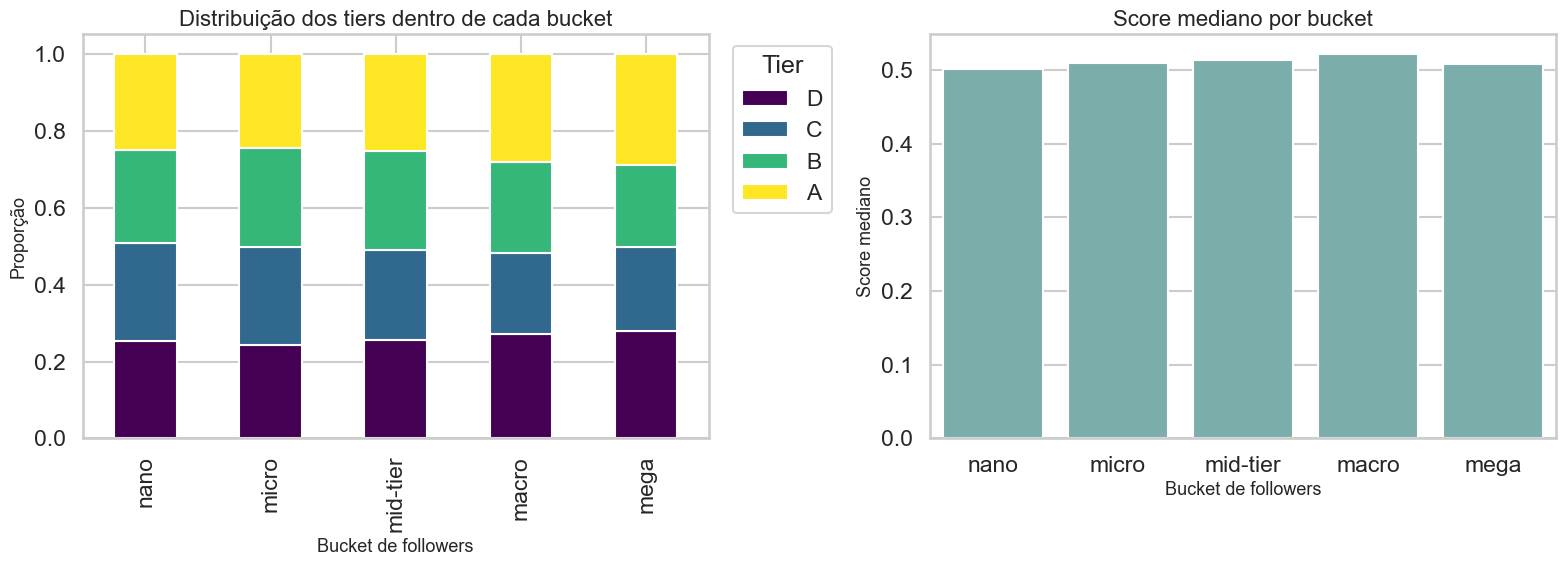

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

dist_bucket_tier.plot(kind="bar", stacked=True, ax=axes[0], colormap="viridis")
axes[0].set_title("Distribuição dos tiers dentro de cada bucket")
axes[0].set_xlabel("Bucket de followers")
axes[0].set_ylabel("Proporção")
axes[0].legend(title="Tier", bbox_to_anchor=(1.02, 1), loc="upper left")

score_bucket = (
    perfis_valid
    .group_by("bucket_followers")
    .agg(pl.col("score_audiencia").median().alias("score_mediano"))
    .to_pandas()
)
score_bucket["bucket_followers"] = pd.Categorical(score_bucket["bucket_followers"], categories=ORDEM_BUCKET, ordered=True)
score_bucket = score_bucket.sort_values("bucket_followers")

sns.barplot(data=score_bucket, x="bucket_followers", y="score_mediano", ax=axes[1], color="#72B7B2")
axes[1].set_title("Score mediano por bucket")
axes[1].set_xlabel("Bucket de followers")
axes[1].set_ylabel("Score mediano")

plt.tight_layout()
plt.show()

### Teste Qui-Quadrado de aderência

In [68]:
resultados_h4 = []

In [69]:
for bucket in ORDEM_BUCKET:
    sub = perfis.filter(pl.col("bucket_followers") == bucket)
    n_total = len(sub)
    
    if n_total == 0:
        continue
    
    # Contagem observada por tier
    contagem = (
        sub.group_by("tier_audiencia")
        .agg(pl.len().alias("n"))
        .with_columns(pl.col("tier_audiencia").cast(pl.Enum(ORDEM_TIER)))
        .sort("tier_audiencia")
    )
    
    observado = contagem["n"].to_list()
    
    # Se não tem todos os 4 tiers, preencher com zeros
    tiers_presentes = contagem["tier_audiencia"].to_list()
    obs_dict = dict(zip(tiers_presentes, observado))
    obs_completo = [obs_dict.get(t, 0) for t in ORDEM_TIER]
    
    # Distribuição esperada: uniforme (n_total / 4 para cada tier)
    esperado = [n_total / 4] * 4
    
    chi2, p_value = chisquare(obs_completo, f_exp=esperado)
    
    print(f"\nBucket: {bucket} (n={n_total})")
    for t, o, e in zip(ORDEM_TIER, obs_completo, esperado):
        print(f"  Tier {t}: observado={o}, esperado={e:.1f}")
    print(f"  Chi² = {chi2:.4f}, p = {p_value:.6f}")
    
    resultados_h4.append({
        "bucket": bucket,
        "n_total": n_total,
        "chi2": chi2,
        "p_value": p_value,
        "uniforme": p_value > 0.05  # Não rejeitamos uniformidade
    })



Bucket: nano (n=12209)
  Tier D: observado=3102, esperado=3052.2
  Tier C: observado=3106, esperado=3052.2
  Tier B: observado=2937, esperado=3052.2
  Tier A: observado=3064, esperado=3052.2
  Chi² = 6.1544, p = 0.104336

Bucket: micro (n=15411)
  Tier D: observado=3747, esperado=3852.8
  Tier C: observado=3907, esperado=3852.8
  Tier B: observado=3981, esperado=3852.8
  Tier A: observado=3776, esperado=3852.8
  Chi² = 9.4646, p = 0.023711

Bucket: mid-tier (n=3986)
  Tier D: observado=1018, esperado=996.5
  Tier C: observado=938, esperado=996.5
  Tier B: observado=1017, esperado=996.5
  Tier A: observado=1013, esperado=996.5
  Chi² = 4.5931, p = 0.204137

Bucket: macro (n=667)
  Tier D: observado=181, esperado=166.8
  Tier C: observado=140, esperado=166.8
  Tier B: observado=159, esperado=166.8
  Tier A: observado=187, esperado=166.8
  Chi² = 8.3283, p = 0.039692

Bucket: mega (n=736)
  Tier D: observado=205, esperado=184.0
  Tier C: observado=161, esperado=184.0
  Tier B: observado=

In [70]:
df_h4 = pl.DataFrame(resultados_h4)
print("Resumo H4:")
print(df_h4)

Resumo H4:
shape: (5, 5)
┌──────────┬─────────┬───────────┬──────────┬──────────┐
│ bucket   ┆ n_total ┆ chi2      ┆ p_value  ┆ uniforme │
│ ---      ┆ ---     ┆ ---       ┆ ---      ┆ ---      │
│ str      ┆ i64     ┆ f64       ┆ f64      ┆ f64      │
╞══════════╪═════════╪═══════════╪══════════╪══════════╡
│ nano     ┆ 12209   ┆ 6.154394  ┆ 0.104336 ┆ 1.0      │
│ micro    ┆ 15411   ┆ 9.464603  ┆ 0.023711 ┆ 0.0      │
│ mid-tier ┆ 3986    ┆ 4.593076  ┆ 0.204137 ┆ 1.0      │
│ macro    ┆ 667     ┆ 8.328336  ┆ 0.039692 ┆ 0.0      │
│ mega     ┆ 736     ┆ 13.206522 ┆ 0.004211 ┆ 0.0      │
└──────────┴─────────┴───────────┴──────────┴──────────┘


C:\Users\cruzd\AppData\Local\Temp\ipykernel_26412\560947972.py:19: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\cruzd\AppData\Local\Temp\ipykernel_26412\560947972.py:20: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig("output/fig_h4_chisquare_buckets.png", dpi=150)
c:\Users\cruzd\OneDrive\Área de Trabalho\PIBIC_TCC\influencers_kim\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


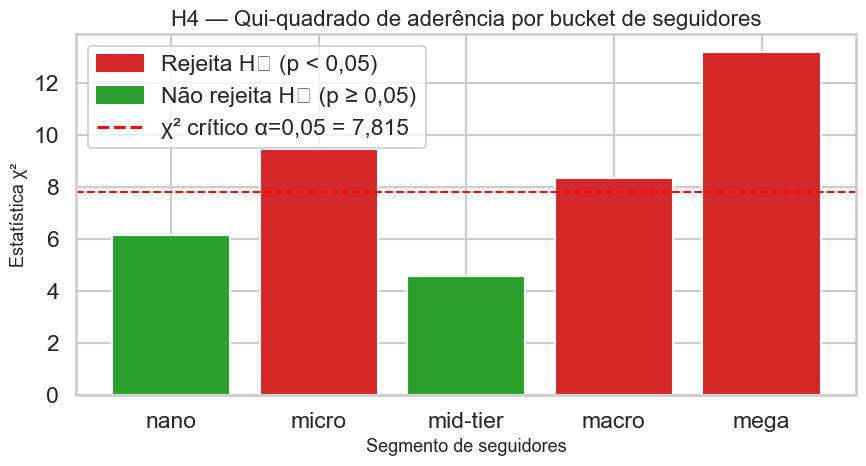

In [71]:
# GRÁFICO H4 — p-valores qui-quadrado por bucket (já calculados em dfh4)
fig, ax = plt.subplots(figsize=(9, 5))

cores = ["#d62728" if p < 0.05 else "#2ca02c" for p in df_h4["p_value"]]
bars = ax.bar(df_h4["bucket"], df_h4["chi2"], color=cores)

ax.axhline(y=7.815, color="red", linestyle="--", linewidth=1.5,
           label="χ² crítico α=0,05 (gl=3) = 7,815")
ax.set_title("H4 — Qui-quadrado de aderência por bucket de seguidores")
ax.set_xlabel("Segmento de seguidores")
ax.set_ylabel("Estatística χ²")

patch_rej = mpatches.Patch(color="#d62728", label="Rejeita H₀ (p < 0,05)")
patch_ok  = mpatches.Patch(color="#2ca02c", label="Não rejeita H₀ (p ≥ 0,05)")
ax.legend(handles=[patch_rej, patch_ok,
          plt.Line2D([0], [0], color='red', linestyle='--')],
          labels=["Rejeita H₀ (p < 0,05)", "Não rejeita H₀ (p ≥ 0,05)",
                  "χ² crítico α=0,05 = 7,815"])
plt.tight_layout()
plt.savefig("output/fig_h4_chisquare_buckets.png", dpi=150)

# 8. Correlações gerais

In [72]:
cols_corr = [c for c in ["score_audiencia", "erclassico_mediana", "erweighted_mediana", "cv"] if c in df_pd.columns]
df_pd[cols_corr].corr(method="spearman")

,score_audiencia,erclassico_mediana,erweighted_mediana,cv
score_audiencia,1.000000,0.803062,0.802663,-0.660393
erclassico_mediana,0.803062,1.000000,0.999967,-0.362144
erweighted_mediana,0.802663,0.999967,1.000000,-0.362055
cv,-0.660393,-0.362144,-0.362055,1.000000
